# Fluxo de trabalho: DEM → HAND (Height Above Nearest Drainage)
# Mapa de suscetibilidade a inundações — **Blumenau/SC**

> **Versão adaptada** do notebook original do Prof. Alex Salazar (Porto Alegre/RS) para a região de **Blumenau/SC**.
> Projeto: **AMERICAS TechGuard** — UniSENAI/SC, Campus Joinville.
> Aluno: Ryan — Atividade Técnica Complementar (Período 6).

Este notebook calcula **HAND** a partir de um **Modelo Digital de Elevação (DEM)** usando **WhiteboxTools** e, em seguida, deriva:

- um **mapa de suscetibilidade a inundações** (4 classes: ALTO, MÉDIO, BAIXO, MUITO_BAIXO);
- discretização determinística baseada em **limiares de HAND em metros** (sensibilidade discutida na Seção 9).

**Recorte territorial:** município de Blumenau (IBGE) + áreas de contribuição ottocodificadas (BHO2017/ANA-SNIRH).

**Justificativa da região:**
Blumenau possui histórico recorrente de inundações (1983, 2008, 2011, 2017, 2023) registrado no Atlas de Desastres do SGB-CPRM, com perdas econômicas e humanas significativas no Vale do Itajaí-Açu. A continuidade com a análise NDVI da Semana 5 (mesma região) permite construir, dentro do AMERICAS TechGuard, uma camada hidrológica complementar à cobertura vegetal.


### Entradas
- **DEM** (GeoTIFF): elevação do terreno.
- Parâmetros da análise hidrológica (por exemplo, limiar de acumulação para extrair a rede de drenagem).

### Saídas principais
- `*_hand.tif`: raster HAND (mesmo sistema de referência/extensão do DEM).

### Saídas opcionais (pós-processamento, sem alterar o pipeline)
- `*_flood_risk_classes.tif`: classes discretas de risco por limiares.
- `*_flood_probability.tif`: probabilidade (0–1) derivada de HAND.


## Recomendações de qualidade dos dados (importante)
- **CRS projetado (metros):** se o seu DEM estiver em lat/long (graus), reprojete para um CRS projetado para que as magnitudes de distância/área sejam coerentes.
- **NoData consistente:** valores NoData incorretos contaminam direção/acumulação de fluxo.
- **Resolução:** a resolução do DEM define o “detalhe” hidrológico; DEMs muito grosseiros suavizam canais e planícies.

## 1) Requisitos e instalação

### Bibliotecas
- **`whitebox` / `WhiteboxTools`**: executa ferramentas de análise hidrológica e geomorfométrica (fill/breach depressions, fluxo D8, acumulação, extração de drenagens, HAND).

## Glossário rápido de termos do pipeline

- **DEM (Digital Elevation Model)**: raster onde cada pixel armazena elevação (idealmente em metros).
- **Depressão / sink**: conjunto de células onde o fluxo fica preso sem saída para uma célula mais baixa (pode ser real ou um artefato).
- **Fill depressions**: remove sinks elevando o terreno no mínimo necessário para garantir saída.
- **Breach depressions least cost**: remove sinks criando um “corte” até a saída minimizando a modificação do relevo.
- **DEM conditioning**: conjunto de passos para que o DEM seja hidrologicamente consistente (sem artefatos que quebrem a conectividade do fluxo).
- **D8 pointer (direção de fluxo)**: raster que codifica para qual dos 8 vizinhos escoa cada célula.
- **D8 flow accumulation (acumulação)**: raster que quantifica a contribuição a montante para cada célula (em #células ou área).
- **Stream extraction (extração de drenagens)**: define a rede de canais aplicando um limiar sobre a acumulação.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# Configuração de entrada (AJUSTE AQUI)
# ============================================================

projectName = "HAND"             # Nome EXATO da pasta do projeto dentro do Drive
numProjetos = 1                  # Quantos caminhos (pastas com o mesmo nome) você quer retornar (>=1)
profundidadeMax = 8              # Profundidade máxima de busca (1 a 8)

# ============================================================
# Montagem / raiz do Google Drive
# ============================================================

import os
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
except Exception as e:
    # Se não estiver no Colab, não falha; apenas informa.
    print("Aviso: não foi possível montar o Drive automaticamente (talvez não esteja no Colab).")
    print("Detalhe:", e)

raizDrive = Path("/content/drive/MyDrive")

if not raizDrive.exists():
    raise FileNotFoundError(
        "Não encontrei a raiz do Drive em '/content/drive/MyDrive'. "
        "Verifique se o Drive está montado e se o caminho está correto."
    )

# ============================================================
# Validações de entrada
# ============================================================

if not isinstance(projectName, str) or not projectName.strip():
    raise ValueError("A variável 'projectName' deve ser uma string não vazia.")

if not isinstance(numProjetos, int) or numProjetos < 1:
    raise ValueError("A variável 'numProjetos' deve ser um inteiro >= 1.")

if not isinstance(profundidadeMax, int) or profundidadeMax < 1:
    raise ValueError("A variável 'profundidadeMax' deve ser um inteiro >= 1.")

# Força o limite máximo pedido (até 8)
profundidadeMax = min(profundidadeMax, 8)

# ============================================================
# Busca da pasta do projeto até profundidadeMax
# ============================================================

def encontrar_pastas_por_nome(raiz: Path, nome_pasta: str, profundidade_max: int, limite: int = 1):
    """
    Procura pastas com nome 'nome_pasta' dentro de 'raiz', varrendo recursivamente até 'profundidade_max'.
    Retorna uma lista de Paths (tamanho no máximo 'limite').
    """
    resultados = []

    # BFS por níveis (controla profundidade de forma determinística)
    fila = [(raiz, 0)]

    while fila and len(resultados) < limite:
        atual, profundidade = fila.pop(0)

        if profundidade >= profundidade_max:
            continue

        try:
            for item in atual.iterdir():
                if item.is_dir():
                    if item.name == nome_pasta:
                        resultados.append(item)
                        if len(resultados) >= limite:
                            break
                    # continua descendo
                    fila.append((item, profundidade + 1))
        except PermissionError:
            # Se houver alguma pasta sem permissão de leitura, apenas ignora
            continue

    return resultados

pastasEncontradas = encontrar_pastas_por_nome(
    raiz=raizDrive,
    nome_pasta=projectName.strip(),
    profundidade_max=profundidadeMax,
    limite=numProjetos
)

if not pastasEncontradas:
    raise FileNotFoundError(
        f"Não foi encontrada nenhuma pasta chamada '{projectName}' dentro de {raizDrive} "
        f"com profundidade máxima {profundidadeMax}."
    )

# Se houver mais de uma, por padrão usa a primeira (mas você tem a lista completa)
diretorioEntrada = pastasEncontradas[0]

print("Pasta(s) encontrada(s):")
for i, p in enumerate(pastasEncontradas, start=1):
    print(f"  {i}. {p}")

print("\nDiretório de entrada definido como:")
print(diretorioEntrada)

# (Opcional) torna o diretório de entrada o diretório de trabalho do notebook
os.chdir(diretorioEntrada)
print("\nDiretório de trabalho atual:")
print(Path.cwd())


Pasta(s) encontrada(s):
  1. /content/drive/MyDrive/HAND

Diretório de entrada definido como:
/content/drive/MyDrive/HAND

Diretório de trabalho atual:
/content/drive/.shortcut-targets-by-id/1c3xwubERwOvvHUVoM05nt-PjDbNHrZMi/HAND


In [ ]:
# ============================================================
# Instalação de dependências a partir do diretório do projeto
# Requisitos: a variável 'diretorioEntrada' deve existir (definida no código anterior)
# ============================================================

import os
import sys
import subprocess
from pathlib import Path

# --- validação ---
if "diretorioEntrada" not in globals():
    raise NameError(
        "A variável 'diretorioEntrada' não foi encontrada. "
        "Execute primeiro o bloco que localiza a pasta do projeto no Drive."
    )

diretorioEntrada = Path(diretorioEntrada)
if not diretorioEntrada.exists():
    raise FileNotFoundError(f"O diretório de entrada não existe: {diretorioEntrada}")

print(f"Diretório do projeto: {diretorioEntrada}")

# ============================================================
# Funções auxiliares
# ============================================================

def run_cmd(cmd, cwd=None):
    """Executa um comando e falha com mensagem clara se der erro."""
    print("\nExecutando:", " ".join(cmd))
    res = subprocess.run(cmd, cwd=str(cwd) if cwd else None, text=True, capture_output=True)
    if res.stdout:
        print(res.stdout)
    if res.returncode != 0:
        if res.stderr:
            print(res.stderr)
        raise RuntimeError(f"Falha ao executar o comando: {' '.join(cmd)}")
    return res

def pip_install_requirements(req_file: Path):
    # Atualiza pip e instala requirements
    run_cmd([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
    run_cmd([sys.executable, "-m", "pip", "install", "-r", str(req_file)])

def pip_install_editable(project_dir: Path):
    run_cmd([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
    run_cmd([sys.executable, "-m", "pip", "install", str(project_dir)])

# ============================================================
# Estratégia de detecção de arquivos de dependência
# ============================================================

candidatos = [
    "requirements.txt",
    "requirements-dev.txt",
    "requirements/requirements.txt",
    "requirements/base.txt",
]

req_encontrado = None
for rel in candidatos:
    p = diretorioEntrada / rel
    if p.exists() and p.is_file():
        req_encontrado = p
        break

# (Opcional) fallback: procurar qualquer arquivo requirements*.txt na raiz
if req_encontrado is None:
    for p in sorted(diretorioEntrada.glob("requirements*.txt")):
        if p.is_file():
            req_encontrado = p
            break

# ============================================================
# Instalação
# ============================================================

if req_encontrado:
    print(f"Arquivo de requisitos encontrado: {req_encontrado}")
    pip_install_requirements(req_encontrado)
    print("Instalação finalizada com sucesso via requirements.")
else:
    # Se não houver requirements.txt, tenta instalar como pacote Python (pyproject/setup.py)
    tem_pyproject = (diretorioEntrada / "pyproject.toml").exists()
    tem_setup = (diretorioEntrada / "setup.py").exists() or (diretorioEntrada / "setup.cfg").exists()

    if tem_pyproject or tem_setup:
        print("Não encontrei requirements.txt. Tentando instalar o projeto como pacote Python...")
        pip_install_editable(diretorioEntrada)
        print("Instalação finalizada com sucesso via instalação do projeto.")
    else:
        raise FileNotFoundError(
            "Não encontrei um arquivo de requisitos (ex.: requirements.txt) "
            "nem um projeto instalável (pyproject.toml / setup.py / setup.cfg) "
            f"em: {diretorioEntrada}"
        )

Diretório do projeto: /content/drive/MyDrive/HAND
Arquivo de requisitos encontrado: /content/drive/MyDrive/HAND/requirements.txt

Executando: /usr/bin/python3 -m pip install --upgrade pip


Executando: /usr/bin/python3 -m pip install -r /content/drive/MyDrive/HAND/requirements.txt

Instalação finalizada com sucesso via requirements.


In [ ]:
# =============================
# Bibliotecas padrão (stdlib)
# import json
import os
import sys
import zipfile
from pathlib import Path

# =============================
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import planetary_computer
import rasterio
import requests
import rioxarray as rxr
import xarray as xr
from pystac_client import Client
from rasterio.mask import mask
from shapely.ops import unary_union
import fiona


# WhiteboxTools: motor do pipeline hidrológico
try:
    from whitebox.whitebox_tools import WhiteboxTools
except Exception as e:
    print(f"Erro {e}: pacote 'whitebox' não encontrado. Instale com: pip install whitebox", file=sys.stderr)
    raise

# (Opcional) stack de análise/visualização de rasters
try:
    import numpy as np
    import rasterio
    # from rasterio.enums import Resampling
    import matplotlib.pyplot as plt
except Exception:
    np = None
    rasterio = None
    plt = None


## 2) Funções auxiliares

Estas funções fazem duas coisas:

1. **Validação de entradas numéricas** (por exemplo, garantir que o limiar de acumulação seja positivo).
2. Manter um comportamento equivalente ao script original, mas com erros mais explícitos caso algo venha errado.

- `positive_int`: força inteiro positivo (útil para `threshold_cells`).
- `positive_float`: força float positivo (útil se converter área ou tamanho de célula).



In [ ]:
import argparse

def positive_int(value):
    """Converte para int e verifica se é > 0."""
    ivalue = int(value)
    if ivalue <= 0:
        raise argparse.ArgumentTypeError("El valor debe ser un entero positivo")
    return ivalue

def positive_float(value):
    """Converte para float e verifica se é > 0."""
    fvalue = float(value)
    if fvalue <= 0:
        raise argparse.ArgumentTypeError("El valor debe ser un número positivo")
    return fvalue


## 3) Entradas (inputs) e saídas (outputs)

Nesta célula você define os parâmetros do fluxo.

### Parâmetros-chave
- `dem`: caminho para o DEM (GeoTIFF).
- `outdir`: pasta de saída.
- `prefix`: prefixo para os arquivos gerados.
- `breach`:
  - `False`: usa `fill_depressions` (preenche depressões).
  - `True`: usa `breach_depressions_least_cost` (rompe depressões com custo mínimo).
- `threshold_cells`: limiar (em número de células) para extração da rede de drenagem.
  - quanto maior, menos canais; quanto menor, mais canais.

### Produtos gerados (principais)
- `*_dem_filled.tif`: DEM condicionado (preenchido/rompido).
- `*_d8_pointer.tif`: direção de fluxo D8.
- `*_d8_accum.tif`: acumulação de fluxo D8.
- `*_streams.tif`: rede de drenagem (binária).
- `*_hand.tif`: HAND (metros acima da drenagem mais próxima).


### Influência de `threshold_cells` no resultado (e no tempo)

Do ponto de vista hidrológico, `threshold_cells` controla o tamanho mínimo de bacia (em células) para formar um canal.

- Se **aumentar** `threshold_cells`: você obtém **menos** canais; o HAND tende a referenciar drenagens principais.
- Se **reduzir** `threshold_cells`: você obtém **mais** canais; o HAND fica mais “local” (mais drenagens pequenas).

Em termos computacionais, isso influencia principalmente `extract_streams` e (dependendo do tamanho do DEM) pode alterar tempos e tamanho de arquivos.



## 3) Insumos oficiais (ANA + IBGE) para **Blumenau/SC**: DEM e Áreas de Contribuição (Ottobacias)

Nesta seção, preparamos os insumos que alimentarão o pipeline HAND:

1. **Limite municipal de Blumenau (IBGE Malhas Municipais 2023)**
   - Download da Malha Municipal do IBGE (preferencialmente Brasil completo; fallback Santa Catarina)
   - Filtragem por `NM_MUN == "BLUMENAU"` e `SIGLA_UF == "SC"` (ou `CD_UF == "42"`)

2. **Ottobacias BHO2017 (ANA/SNIRH)** — áreas de contribuição que intersectam o município
   - Consulta ArcGIS REST por BBox do limite de Blumenau
   - Filtro por nível ottocodificado (`nunivotto`)
   - União das geometrias → contorno final para recorte do DEM

3. **DEM** — ANADEM (primário, tile MGRS 22J) ou Copernicus GLO-30 (fallback via Microsoft Planetary Computer)

> **Mudança crítica em relação ao original:** o bloco `except` do código original carregava dados de respaldo de Porto Alegre se o download falhasse. Como esses respaldos não existem para Blumenau, substituímos por um `raise` explícito — assim qualquer falha de rede interrompe o pipeline em vez de gerar resultado contaminado por dados de outra cidade.


# Fluxo de trabalho: DEM (download e recorte para Blumenau/SC)

In [ ]:
# =========================================================
# [3.1] Baixar limites municipais (IBGE) e ottobacias (ANA/BHO),
#       depois selecionar áreas de contribuição que intersectam Blumenau/SC
# =========================================================
#
# Adaptado de Porto Alegre/RS para Blumenau/SC (Vale do Itajaí-Açu).
#
# Produtos (em outdir):
#   - blumenau_boundary.gpkg
#   - ottobacias_blumenau_raw.gpkg              (todas as que intersectam)
#   - ottobacias_blumenau_by_level.gpkg         (filtradas por nível Otto)
#   - ottobacias_blumenau_union.gpkg            (contorno final para recorte do DEM)

# -------------------------
# Diretório de saída
# -------------------------
if "outdir" not in globals():
    outdir = Path("outputs_dem")
outdir = Path(outdir)
outdir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Parâmetros (ADAPTAÇÃO BLUMENAU)
# -------------------------
# 1) Ano da malha municipal do IBGE (2023 é estável)
IBGE_MUNICIPIOS_YEAR = 2023

# 2) Nome do município e UF
TARGET_MUNICIPIO = "BLUMENAU"
TARGET_UF_SIGLA = "SC"
TARGET_UF_CODE = "42"           # Código IBGE de Santa Catarina
TARGET_UF_NOME = "SANTA CATARINA"

# 3) Filtro por nível ottocodificado (nunivotto).
#    O Vale do Itajaí-Açu tem hierarquia ottocodificada diferente da bacia do Guaíba (POA).
#    Estratégia: tenta [5], depois [4], depois [6], depois None (todas).
CONTRIBUTION_LEVELS_PRIORITY = [[5], [4], [6], None]

# 4) Recortar também pelo limite municipal?
#    True => DEM final = contribuição ∩ município (recorte mais apertado)
#    False => DEM final = todas as ottobacias que tocam Blumenau (recorte maior, captura cabeceiras a montante)
#    Para HAND, é INTERESSANTE manter False, pois precisamos das cabeceiras a montante para o cálculo de drenagem.
CLIP_TO_MUNICIPALITY = False

# -------------------------
# Caminhos de saída
# -------------------------
ibge_zip = outdir / f"BR_Municipios_{IBGE_MUNICIPIOS_YEAR}.zip"
ibge_extract_dir = outdir / f"ibge_municipios_{IBGE_MUNICIPIOS_YEAR}"

mun_gpkg = outdir / "blumenau_boundary.gpkg"
ottos_raw_gpkg = outdir / "ottobacias_blumenau_raw.gpkg"
ottos_lvl_gpkg = outdir / "ottobacias_blumenau_by_level.gpkg"
ottos_union_gpkg = outdir / "ottobacias_blumenau_union.gpkg"

# =========================================================
# 1) Baixar Malha Municipal IBGE (Brasil) — fallback SC
# =========================================================
ibge_url_br = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/"
    f"malhas_municipais/municipio_{IBGE_MUNICIPIOS_YEAR}/Brasil/"
    f"BR_Municipios_{IBGE_MUNICIPIOS_YEAR}.zip"
)

ibge_url_uf = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/"
    f"malhas_municipais/municipio_{IBGE_MUNICIPIOS_YEAR}/UFs/{TARGET_UF_SIGLA}/"
    f"{TARGET_UF_SIGLA}_Municipios_{IBGE_MUNICIPIOS_YEAR}.zip"
)

def download(url: str, dst: Path, timeout=180):
    r = requests.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    dst.write_bytes(r.content)

if not ibge_zip.exists():
    try:
        print(f"Baixando malha municipal do IBGE (BR) {IBGE_MUNICIPIOS_YEAR}...")
        download(ibge_url_br, ibge_zip)
        print(" OK (BR).")
    except requests.HTTPError as e:
        print(f"⚠ Falhou BR ({e}). Tentando {TARGET_UF_SIGLA}...")
        ibge_zip = outdir / f"{TARGET_UF_SIGLA}_Municipios_{IBGE_MUNICIPIOS_YEAR}.zip"
        download(ibge_url_uf, ibge_zip)
        print(f" OK ({TARGET_UF_SIGLA}).")
else:
    print(" ZIP do IBGE já existe. OK.")

if not ibge_extract_dir.exists():
    print("Extraindo ZIP do IBGE...")
    ibge_extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ibge_zip, "r") as zf:
        zf.extractall(ibge_extract_dir)
    print(" Extraído.")
else:
    print(" ZIP do IBGE já extraído. OK.")

# localizar shapefile
shps = list(ibge_extract_dir.rglob("*.shp"))
if not shps:
    raise FileNotFoundError(f"Não foi encontrado .shp dentro de {ibge_extract_dir}")
ibge_shp = shps[0]
print(f"Shapefile do IBGE encontrado: {ibge_shp.name}")

mun = gpd.read_file(ibge_shp)

# =========================================================
# 2) Extrair Blumenau (SC) e salvar boundary
# =========================================================
if "NM_MUN" not in mun.columns:
    raise KeyError(f"Não encontrei NM_MUN. Colunas: {mun.columns.tolist()}")

mun_up = mun["NM_MUN"].astype(str).str.strip().str.upper()

# --- detecção robusta de Blumenau (SC) ---
target = None

if "SIGLA_UF" in mun.columns:
    target = mun[
        (mun_up == TARGET_MUNICIPIO) &
        (mun["SIGLA_UF"].astype(str).str.upper() == TARGET_UF_SIGLA)
    ].copy()

elif "CD_UF" in mun.columns:
    target = mun[
        (mun_up == TARGET_MUNICIPIO) &
        (mun["CD_UF"].astype(str) == TARGET_UF_CODE)
    ].copy()

elif "NM_UF" in mun.columns:
    target = mun[
        (mun_up == TARGET_MUNICIPIO) &
        (mun["NM_UF"].astype(str).str.upper() == TARGET_UF_NOME)
    ].copy()

else:
    raise KeyError(f"Não encontrei um campo UF válido. Colunas: {mun.columns.tolist()}")

if target.empty:
    raise ValueError(f"Não foi encontrado {TARGET_MUNICIPIO} ({TARGET_UF_SIGLA}) na malha municipal.")

target = target.to_crs(4326)
target.to_file(mun_gpkg, layer="blumenau", driver="GPKG")
print(f" Limite municipal de Blumenau salvo: {mun_gpkg}")
print(f" Área aproximada: {target.to_crs(3857).geometry.area.sum() / 1e6:.1f} km²")

# =========================================================
# 3) Consultar ottobacias BHO (ArcGIS REST) por BBOX
# =========================================================
BHO_QUERY_URL = "https://www.snirh.gov.br/arcgis/rest/services/SPR/BHO2017_50K_AREADRENAGEM/MapServer/0/query"

target_3857 = target.to_crs(3857)
xmin, ymin, xmax, ymax = target_3857.total_bounds

# expandir bbox em 10 km para capturar cabeceiras a montante (importante para HAND)
buffer_m = 10000
xmin -= buffer_m; ymin -= buffer_m; xmax += buffer_m; ymax += buffer_m
print(f" BBox de consulta (com buffer de {buffer_m/1000:.0f} km): "
      f"({xmin:.0f}, {ymin:.0f}, {xmax:.0f}, {ymax:.0f}) em EPSG:3857")

def arcgis_query_geojson_bbox(url, bbox, where="1=1", page_size=2000, timeout=180, inSR=3857, outSR=3857):
    xmin_, ymin_, xmax_, ymax_ = bbox
    features = []
    offset = 0
    while True:
        params = {
            "f": "geojson",
            "where": where,
            "outFields": "*",
            "returnGeometry": "true",
            "spatialRel": "esriSpatialRelIntersects",
            "geometryType": "esriGeometryEnvelope",
            "geometry": f"{xmin_},{ymin_},{xmax_},{ymax_}",
            "inSR": inSR,
            "outSR": outSR,
            "resultRecordCount": page_size,
            "resultOffset": offset,
        }
        r = requests.post(url, data=params, timeout=timeout)
        r.raise_for_status()
        data = r.json()
        if "error" in data:
            raise RuntimeError(f"Erro ArcGIS: {data['error']}")
        page_feats = data.get("features", [])
        features.extend(page_feats)
        if len(page_feats) < page_size:
            break
        offset += page_size
    return {"type": "FeatureCollection", "features": features}

# tenta níveis em ordem de prioridade
ottos_3857 = None
chosen_level = None
for levels in CONTRIBUTION_LEVELS_PRIORITY:
    where = "1=1" if levels is None else f"nunivotto IN ({','.join(map(str, levels))})"
    print(f"Consultando ottobacias com filtro: {where}")
    try:
        gj = arcgis_query_geojson_bbox(
            BHO_QUERY_URL,
            bbox=(xmin, ymin, xmax, ymax),
            where=where,
            page_size=2000,
            timeout=180,
            inSR=3857, outSR=3857,
        )
        feats = gj.get("features", [])
        if feats:
            ottos_3857 = gpd.GeoDataFrame.from_features(feats).set_crs(3857)
            chosen_level = levels
            print(f" {len(feats)} ottobacias retornadas com nível {levels}.")
            break
        else:
            print(f"  Sem resultados com nível {levels}, tentando próximo...")
    except Exception as e:
        print(f"  Falha na consulta SNIRH com nível {levels}: {e}")

if ottos_3857 is None or ottos_3857.empty:
    raise RuntimeError(
        "SNIRH não retornou nenhuma ottobacia para Blumenau em nenhum dos níveis testados. "
        "Verifique conectividade com snirh.gov.br ou rode novamente mais tarde."
    )

print(f" Nível ottocodificado adotado: {chosen_level}")

# Interseção exata local com o município (não apenas com o bbox)
ottos_3857 = ottos_3857[ottos_3857.intersects(target_3857.geometry.iloc[0])].copy()
print(f" Ottobacias intersectando Blumenau (após filtro local): {len(ottos_3857)}")

if ottos_3857.empty:
    raise ValueError("Após filtrar por interseção exata, não restou nenhuma ottobacia para Blumenau.")

# Guardar raw (em 4326 para interoperabilidade)
ottos = ottos_3857.to_crs(4326)
ottos.to_file(ottos_raw_gpkg, layer="ottobacias_raw", driver="GPKG")
print(f" Ottobacias intersectantes salvas (raw): {ottos_raw_gpkg}")

# =========================================================
# 4) Unir (contorno final) para recorte do DEM
# =========================================================
ottos_f_3857 = ottos.to_crs(3857)
union_geom = unary_union(ottos_f_3857.geometry)

if CLIP_TO_MUNICIPALITY:
    union_geom = union_geom.intersection(target_3857.geometry.iloc[0])

union_gdf = gpd.GeoDataFrame(
    {"name": ["contrib_union_blumenau"]},
    geometry=[union_geom],
    crs=3857,
).to_crs(4326)
union_gdf.to_file(ottos_union_gpkg, layer="contrib_union", driver="GPKG")

print(f" Contorno de união (para recorte do DEM) salvo: {ottos_union_gpkg}")
print(f" Área do contorno final: {union_gdf.to_crs(3857).geometry.area.sum() / 1e6:.1f} km²")


 ZIP do IBGE já existe. OK.
 ZIP do IBGE já extraído. OK.
Shapefile do IBGE encontrado: BR_Municipios_2023.shp
 Limite municipal de Blumenau salvo: outputs_dem/blumenau_boundary.gpkg
 Área aproximada: 654.5 km²
 BBox de consulta (com buffer de 10 km): (-5487075, -3150045, -5446001, -3065213) em EPSG:3857
Consultando ottobacias com filtro: nunivotto IN (5)
  Sem resultados com nível [5], tentando próximo...
Consultando ottobacias com filtro: nunivotto IN (4)
  Sem resultados com nível [4], tentando próximo...
Consultando ottobacias com filtro: nunivotto IN (6)
  Sem resultados com nível [6], tentando próximo...
Consultando ottobacias com filtro: 1=1
 50 ottobacias retornadas com nível None.
 Nível ottocodificado adotado: None
 Ottobacias intersectando Blumenau (após filtro local): 19
 Ottobacias intersectantes salvas (raw): outputs_dem/ottobacias_blumenau_raw.gpkg
 Contorno de união (para recorte do DEM) salvo: outputs_dem/ottobacias_blumenau_union.gpkg
 Área do contorno final: 2228.1 k

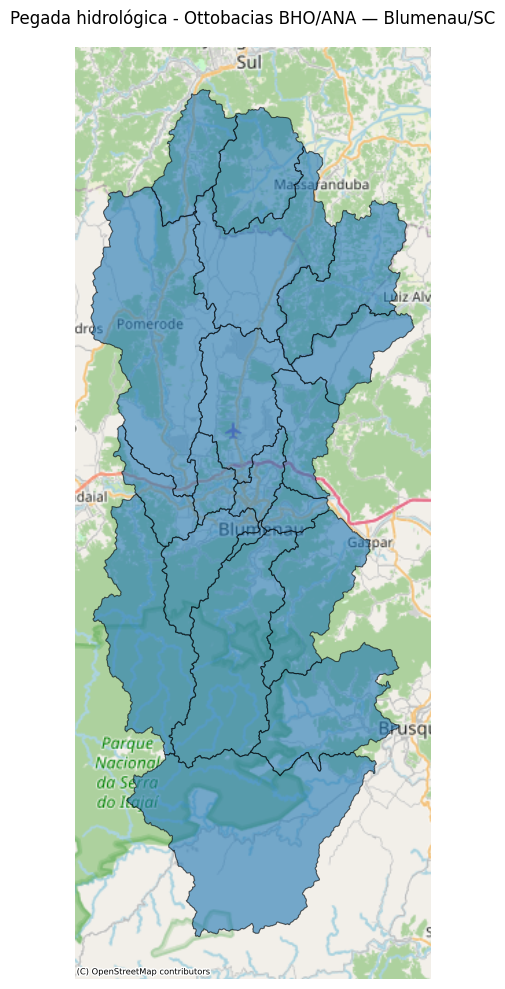

In [ ]:
# Verificar CRS
if ottos.crs is None:
    raise ValueError("O GeoDataFrame 'ottos' não possui CRS definido.")

# Reprojetar para Web Mercator (EPSG:3857) para usar basemap
ottos_3857 = ottos.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot da geometria
ottos_3857.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.6
)

# Mapa de fundo
cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,
    attribution_size=6
)
ax.set_axis_off()

ax.set_title("Pegada hidrológica - Ottobacias BHO/ANA — Blumenau/SC", fontsize=12)

plt.tight_layout()
plt.savefig(outdir / "fig01_ottobacias_blumenau.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# =========================================================
# [3.2] Baixar o DEM e recortá-lo pelo contorno de contribuição
# =========================================================
# Estratégia:
#   1. Tenta ANADEM (ANA/UFRGS) — tile MGRS 22J cobre Blumenau (~26.9°S, 49.07°W).
#   2. Se falhar (403/timeout), usa Copernicus DEM GLO-30 via Microsoft Planetary Computer.
#
# Produtos (em outdir):
#   - dem_source.tif               (DEM baixado)
#   - dem_contrib_clipped.tif      (DEM recortado pelo contorno de contribuição)

union_gdf = gpd.read_file(ottos_union_gpkg, layer="contrib_union")
union_3857 = union_gdf.to_crs(3857)
bbox = union_3857.total_bounds  # xmin, ymin, xmax, ymax (m)

dem_download = outdir / "dem_source.tif"
dem_clipped = outdir / "dem_contrib_clipped.tif"

# -------------------------
# Opção A: ANADEM (por tile MGRS)
# -------------------------
# Blumenau (~26.9°S, 49.07°W) cai na zona MGRS 22, banda J (banda J cobre 24°S–32°S).
# Mesmo tile que Porto Alegre (~30°S, 51°W), mas com recorte diferente.

ANADEM_TILE = "22J"
ANADEM_URL = f"https://metadados.snirh.gov.br/files/anadem_v1_tiles/anadem_v1_{ANADEM_TILE}.tif"

def try_download_anadem(dst: Path) -> bool:
    try:
        print(f"Tentando baixar o tile ANADEM {ANADEM_TILE}...")
        r = requests.get(ANADEM_URL, timeout=300, headers={"User-Agent": "Mozilla/5.0"})
        if r.status_code != 200:
            print(f"ANADEM não acessível (HTTP {r.status_code}). Usando fallback Copernicus.")
            return False
        dst.write_bytes(r.content)
        print(f" ANADEM baixado ({len(r.content) / 1e6:.1f} MB).")
        return True
    except Exception as e:
        print(f"Falha no download do ANADEM: {e}. Usando fallback Copernicus.")
        return False

# -------------------------
# Opção B (fallback): Copernicus DEM GLO-30 (Planetary Computer)
# -------------------------
def download_copernicus_dem(dst: Path, bbox_4326):
    """Mosaica os tiles necessários e recorta para o bbox."""
    print("Buscando tiles Copernicus GLO-30 no Planetary Computer...")
    catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    search = catalog.search(collections=["cop-dem-glo-30"], bbox=bbox_4326)
    items = list(search.get_items())
    if len(items) == 0:
        raise RuntimeError("Nenhum tile Copernicus encontrado para o bbox.")
    print(f" {len(items)} tile(s) Copernicus encontrado(s).")

    # Se múltiplos tiles, mosaica; senão, usa o único.
    if len(items) == 1:
        item = planetary_computer.sign(items[0])
        href = item.assets["data"].href
        d = rxr.open_rasterio(href, masked=True).squeeze()
        d.rio.to_raster(dst)
    else:
        # Mosaico simples via merge
        from rasterio.merge import merge as rio_merge
        srcs = []
        for it in items:
            it = planetary_computer.sign(it)
            srcs.append(rasterio.open(it.assets["data"].href))
        mosaic, transform = rio_merge(srcs)
        out_meta = srcs[0].meta.copy()
        out_meta.update({
            "height": mosaic.shape[1],
            "width": mosaic.shape[2],
            "transform": transform,
        })
        with rasterio.open(dst, "w", **out_meta) as o:
            o.write(mosaic)
        for s in srcs:
            s.close()
    print(f" DEM Copernicus salvo: {dst.name}")

# -------------------------
# Baixar DEM
# -------------------------
if not dem_download.exists():
    ok = try_download_anadem(dem_download)
    if not ok:
        union_4326 = union_gdf.to_crs(4326)
        bbox_4326 = union_4326.total_bounds.tolist()
        print("Baixando Copernicus DEM (fallback) para bbox:", bbox_4326)
        download_copernicus_dem(dem_download, bbox_4326)
else:
    print("DEM já baixado. OK.")

# -------------------------
# Recorte DEM pelo contorno
# -------------------------
with rasterio.open(dem_download) as src:
    union_dem_crs = union_gdf.to_crs(src.crs)
    geoms = [union_dem_crs.geometry.iloc[0].__geo_interface__]

    out_img, out_transform = mask(src, geoms, crop=True)

    # Pixels 0 → NoData (zonas oceânicas/sem dado em DEMs globais)
    nodata_val = -32768
    out_img[out_img == 0] = nodata_val
    out_img = out_img.astype("int16")

    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_img.shape[1],
        "width": out_img.shape[2],
        "transform": out_transform,
        "dtype": "int16",
        "nodata": nodata_val,
    })

    with rasterio.open(dem_clipped, "w", **out_meta) as dst:
        dst.write(out_img)

print(f" DEM recortado guardado: {dem_clipped.name}")
print(f" Dimensões: {out_img.shape[1]} x {out_img.shape[2]} pixels")

# Atualiza variável dem para o pipeline HAND
dem = dem_clipped
print("Variável 'dem' atualizada para HAND:", dem)


DEM já baixado. OK.
 DEM recortado guardado: dem_contrib_clipped.tif
 Dimensões: 2809 x 1202 pixels
Variável 'dem' atualizada para HAND: outputs_dem/dem_contrib_clipped.tif


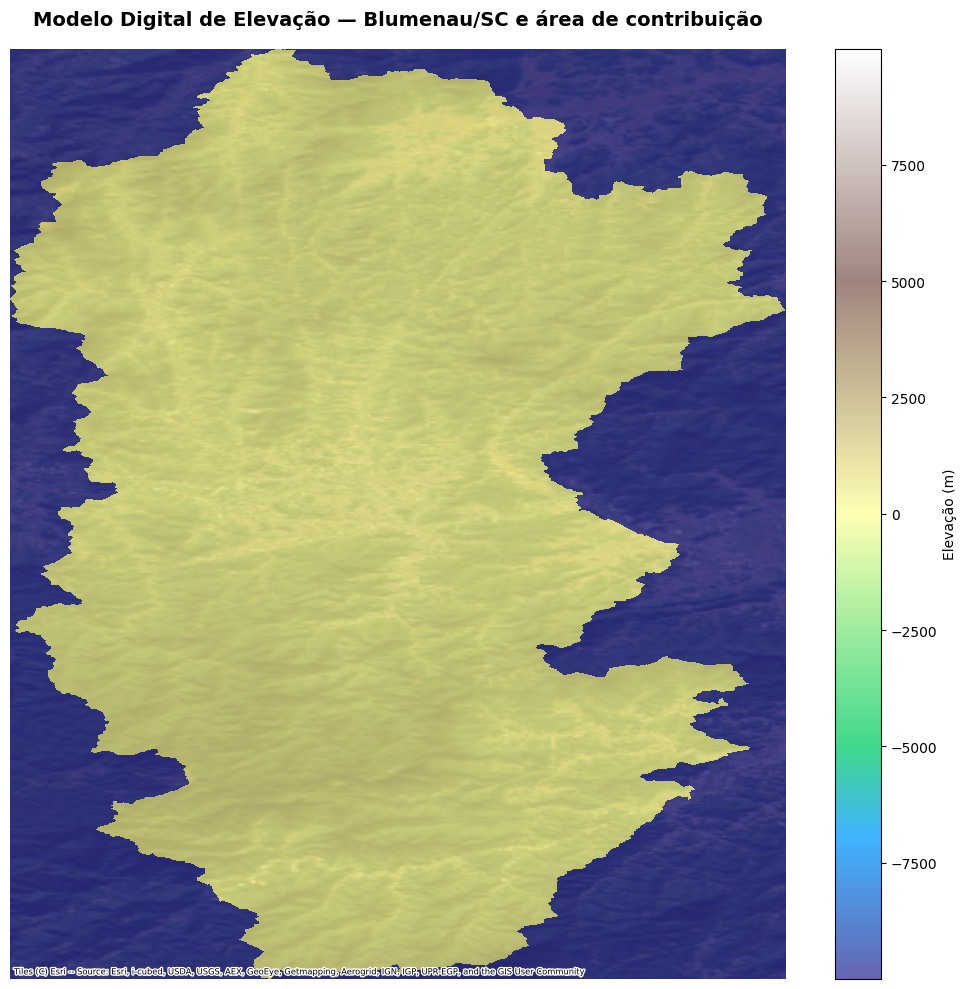

In [ ]:
dem_path = str(dem) if isinstance(dem, Path) else dem

r = (rxr.open_rasterio(dem_path, masked=True)
      .squeeze()
      .rio.reproject(3857)
)

fig, ax = plt.subplots(figsize=(10, 10))

img = r.plot(
    ax=ax,
    cmap="terrain",
    alpha=0.75,
    robust=True,
    add_colorbar=True,
    cbar_kwargs={"label": "Elevação (m)"}
)

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    attribution_size=6
)

ax.set_axis_off()
ax.set_title(
    "Modelo Digital de Elevação — Blumenau/SC e área de contribuição",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.savefig(outdir / "fig02_dem_blumenau.png", dpi=150, bbox_inches="tight")
plt.show()


# Fluxo de trabalho: HAND (Height Above Nearest Drainage)

In [ ]:
# ======================================================
# Parâmetros do pipeline HAND (workspace local pra performance)
# ======================================================
from pathlib import Path
import os, shutil

# Restaura CWD pra pasta do projeto no Drive
if "diretorioEntrada" in dir():
    try:
        os.chdir(str(diretorioEntrada))
    except Exception as e:
        print(f"⚠ {e}. Rode as células de mount Drive antes.")
        raise

# ============================================================
# WORKSPACE LOCAL no SSD do Colab (rápido, não no Drive)
# ============================================================
LOCAL_WORK = Path("/content/work_hand")
LOCAL_WORK.mkdir(parents=True, exist_ok=True)

# Copia DEM do Drive pro disco local (operação única, ~1s)
dem_drive = Path(diretorioEntrada) / "outputs_dem" / "dem_contrib_clipped.tif"
dem_local = LOCAL_WORK / "dem_contrib_clipped.tif"
if not dem_local.exists():
    print("Copiando DEM do Drive pro SSD local...")
    shutil.copy(dem_drive, dem_local)
    print(f" OK ({dem_local.stat().st_size / 1e6:.1f} MB)")
else:
    print("DEM local já existe.")

# Variáveis que o resto do pipeline usa
dem = dem_local       # lê do disco local
outdir = LOCAL_WORK   # WhiteboxTools escreve no disco local

# Parâmetros do pipeline
prefix = "hand_blumenau"
breach = True
threshold_cells = 100
cellsize_m = None
area_km2 = None
keep_intermediates = False

print("\nDEM:", dem)
print("Saída HAND (local, rápida):", outdir)
print("Threshold de drenagem (células):", threshold_cells)

DEM local já existe.

DEM: /content/work_hand/dem_contrib_clipped.tif
Saída HAND (local, rápida): /content/work_hand
Threshold de drenagem (células): 100


## 4) Validação do DEM e cálculo do limiar de canais

Esta etapa garante que:

1. O arquivo de DEM realmente existe.
2. O limiar de extração de drenagens (`threshold_cells`) seja definido de forma coerente.

Regras:

* Se `threshold_cells` **não for None**, ele é validado como um inteiro positivo.
* Se `threshold_cells` for **None**, mas `cellsize_m` e `area_km2` estiverem definidos:

  * Converte-se a área para número de células:

    * `cells = (area_km2 * 1e6) / (cellsize_m²)`

> Isso permite especificar um limiar em termos hidrológicos (“canal a partir de bacias ≥ X km²”), o que costuma ser mais interpretável.

In [ ]:
# Validação
if not dem.exists():
    raise FileNotFoundError(f"DEM não encontrado: {dem}")

# Determina o limiar em número de células
if threshold_cells is not None:
    threshold_cells = positive_int(threshold_cells)
elif (cellsize_m is not None) and (area_km2 is not None):
    cellsize_m = positive_float(cellsize_m)
    area_km2 = positive_float(area_km2)
    threshold_cells = int((area_km2 * 1_000_000.0) / (cellsize_m ** 2))
else:
    raise ValueError("Você deve definir threshold_cells, ou então (cellsize_m e area_km2).")

print("Limiar final (células):", threshold_cells)


Limiar final (células): 100


## 5) Configuração do WhiteboxTools

Aqui é configurado o motor **WhiteboxTools**, responsável pelo processamento hidrológico e geração dos produtos derivados do DEM:

* `work_dir`: diretório onde o Whitebox irá escrever os arquivos temporários e finais.
* `verbose_mode`: imprime logs detalhados, úteis para auditoria e depuração do processo.
* São definidos nomes de saída padronizados (prefixo + sufixos), facilitando rastreabilidade e organização do pipeline.

**Arquivos intermediários típicos**

* DEM condicionado (`*_dem_filled.tif`)
* Direção de fluxo D8 (`*_d8_pointer.tif`)
* Acumulação D8 (`*_d8_accum.tif`)
* Rede de drenagem / streams (`*_streams.tif`)

**Arquivo final**

* HAND (`*_hand.tif`)

In [ ]:
# setup WhiteboxTools

wbt = WhiteboxTools()
wbt.set_verbose_mode(True)
wbt.work_dir = str(outdir.resolve())

# Arquivos de saída (mesma nomenclatura do script)
dem_filled = str(outdir / f"{prefix}_dem_filled.tif")
flow_dir  = str(outdir / f"{prefix}_d8_pointer.tif")
flow_acc  = str(outdir / f"{prefix}_d8_accum.tif")
streams   = str(outdir / f"{prefix}_streams.tif")
hand      = str(outdir / f"{prefix}_hand.tif")

print("Intermediários/Saídas:")
print(" - DEM condicionado:", dem_filled)
print(" - D8 pointer      :", flow_dir)
print(" - D8 acumulação   :", flow_acc)
print(" - Streams         :", streams)
print(" - HAND            :", hand)

Intermediários/Saídas:
 - DEM condicionado: /content/work_hand/hand_blumenau_dem_filled.tif
 - D8 pointer      : /content/work_hand/hand_blumenau_d8_pointer.tif
 - D8 acumulação   : /content/work_hand/hand_blumenau_d8_accum.tif
 - Streams         : /content/work_hand/hand_blumenau_streams.tif
 - HAND            : /content/work_hand/hand_blumenau_hand.tif


## 6) Execução do pipeline (6 etapas)

A seguir executam-se as operações **na mesma ordem do fluxo original**, transformando o DEM bruto em um produto hidrológico consistente:

> **DEM → DEM condicionado → direção de fluxo (D8) → acumulação → rede de drenagem → HAND**

O objetivo é garantir continuidade hidráulica, extrair os canais e, por fim, estimar a altura relativa ao drenagem mais próximo.


### 6.1 O que é condicionamento do DEM?

Condicionar o DEM significa **pré-processá-lo** para que a água escoe corretamente, removendo artefatos numéricos (píxeis isolados, “poças” falsas, ruído topográfico).

Pode incluir:

* **Preenchimento de depressões** (*fill*), ou
* **Abertura de canais artificiais** (*breach*).

Neste notebook usa-se **apenas uma** dessas opções, controlada por `breach`.

### 6.2 Preencher depressões (*Fill depressions*)

Eleva o fundo das depressões até existir uma saída hidrológica.

* Remove sinks espúrios causados por ruído do DEM.
* Produz uma superfície contínua.

**Vantagem:** simples e robusto.
**Limitação:** pode suavizar excessivamente o relevo.

### 6.3 Romper depressões (*Breach least cost*)

Em vez de elevar o terreno, cria um **canal de menor custo** ligando a depressão à jusante.

* Preserva melhor declividades naturais.
* Evita planícies artificiais.

**Vantagem:** maior realismo geomorfológico.
**Limitação:** pode gerar cortes estreitos se o DEM for ruidoso.

### 6.4 Direção de fluxo D8

Cada célula drena para **um único vizinho** (maior declive entre 8 direções).

Saída: raster de ponteiros indicando o sentido do escoamento.
Na prática, define a “seta” de fluxo em cada píxel.

### 6.5 Acumulação D8

Conta quantas células contribuem a montante.

* valores baixos → encostas
* valores altos → vales/canais

É a base para identificar drenagens.

### 6.6 Extração de drenagens

Aplica-se um **limiar de contribuição**:

* `threshold_cells` = mínimo de células para classificar como canal
* menor limiar → rede densa
* maior limiar → apenas rios principais

A rede resultante é uma aproximação dependente da resolução do DEM.

### 6.7 Cálculo HAND (Height Above Nearest Drainage)

Mede a **altura vertical** de cada célula em relação ao canal hidrologicamente conectado mais próximo.

Interpretação:

* HAND baixo → áreas suscetíveis a inundação
* HAND alto → áreas elevadas/seguras

No WhiteboxTools: `elevation_above_stream(dem, streams)`.

### 6.8 Limpeza

Remove arquivos intermediários (DEM condicionado, direção, acumulação, streams).

* economiza espaço
* reduz rastreabilidade

Controlado pela variável `cleanup`.

In [ ]:
# pipeline longo

print("[1/6] Condicionando o DEM (preencher ou romper depressões)...")

if breach:
    wbt.breach_depressions_least_cost(dem=str(dem), output=dem_filled, dist=500)
else:
    wbt.fill_depressions(dem=str(dem), output=dem_filled)

print("[2/6] Calculando direção de fluxo D8 (pointer)...")
wbt.d8_pointer(dem=dem_filled, output=flow_dir)

print("[3/6] Calculando acumulação de fluxo D8 (em células)...")
wbt.d8_flow_accumulation(dem_filled, output=flow_acc, out_type="cells")

print(f"[4/6] Extraindo streams com limiar = {threshold_cells} células...")
wbt.extract_streams(flow_accum=flow_acc, output=streams, threshold=threshold_cells)

print("[5/6] Calculando HAND (Elevation Above Stream)...")
wbt.elevation_above_stream(dem=dem_filled, streams=streams, output=hand)

print(f"[6/6] Concluído! HAND gravado em: {hand}")

if not keep_intermediates:
    for fp in [dem_filled, flow_dir, flow_acc, streams]:
        try:
            os.remove(fp)
        except Exception:
            pass
    print("[i] Intermediários removidos (keep_intermediates=False).")
else:
    print("[i] Intermediários mantidos (keep_intermediates=True).")

[1/6] Condicionando o DEM (preencher ou romper depressões)...
./whitebox_tools --run="BreachDepressionsLeastCost" --wd="/content/work_hand" --dem='/content/work_hand/dem_contrib_clipped.tif' --output='/content/work_hand/hand_blumenau_dem_filled.tif' --dist='500' --min_dist --fill -v --compress_rasters=False

*****************************************
* Welcome to BreachDepressionsLeastCost *
* Powered by WhiteboxTools              *
* www.whiteboxgeo.com                   *
*****************************************
Reading data...
Finding pits: 0%
Finding pits: 1%
Finding pits: 2%
Finding pits: 3%
Finding pits: 4%
Finding pits: 5%
Finding pits: 6%
Finding pits: 7%
Finding pits: 8%
Finding pits: 9%
Finding pits: 10%
Finding pits: 11%
Finding pits: 12%
Finding pits: 13%
Finding pits: 14%
Finding pits: 15%
Finding pits: 16%
Finding pits: 17%
Finding pits: 18%
Finding pits: 19%
Finding pits: 20%
Finding pits: 21%
Finding pits: 22%
Finding pits: 23%
Finding pits: 24%
Finding pits: 25%
Findin

In [ ]:
from google.colab import files
files.download("/content/work_hand/hand_blumenau_hand.tif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7) Limiares de alerta / risco de inundação (entrada do usuário)

Em muitos usos operacionais, valores HAND são traduzidos em **níveis de alerta** (por ex., *Alto/Médio/Baixo*).  
Esta célula define explicitamente esses **limiares como variáveis de entrada**, para que o usuário os ajuste.

### Como ler os limiares?
- Suponha que o HAND esteja em **metros**.
- Um exemplo típico (apenas ilustrativo; você deve calibrar localmente):
  - `alto`  : HAND ≤ 5.0 m  
  - `medio` : 1.0 < HAND ≤ 15.0 m  
  - `bajo`  : 3.0 < HAND ≤ 40.0 m  
  - `muy_bajo`: HAND > 40.0 m

> Ajuste esses valores conforme a hidrologia local, a resolução do DEM e (idealmente) evidência histórica (marcas de inundação, modelagem hidráulica ou curvas vazão–nível).



In [ ]:
# Limiares (em metros de HAND). Devem ser crescentes.
# Padrão (aplicado em POA original): [5, 15, 40]
# - HAND ≤ 5 m   → ALTA suscetibilidade (planícies fluviais ativas, várzeas)
# - 5 < HAND ≤ 15 m → MÉDIA suscetibilidade (terraços fluviais baixos)
# - 15 < HAND ≤ 40 m → BAIXA suscetibilidade
# - HAND > 40 m  → MUITO BAIXA suscetibilidade (encostas, divisores)

hand_thresholds_m = [5, 15, 40]

# Etiquetas
risk_labels = ["ALTO", "MÉDIO", "BAIXO", "MUITO_BAIXO"]

print("Limiares HAND (m):", hand_thresholds_m)
print("Classes:", risk_labels)


Limiares HAND (m): [5, 15, 40]
Classes: ['ALTO', 'MÉDIO', 'BAIXO', 'MUITO_BAIXO']


## 8) Mapa de classes de risco (a partir do HAND)

Gera-se um raster categórico de 4 classes (0–3):
- 0: ALTO
- 1: MEDIO
- 2: BAJO
- 3: MUY_BAJO

**Nota:** isto é uma discretização *determinística* baseada em limiares.



Mapa de classes salvo: /content/work_hand/hand_blumenau_susceptibility_classes.tif
Figura final salva em: /content/work_hand/hand_blumenau_susceptibility_map.png


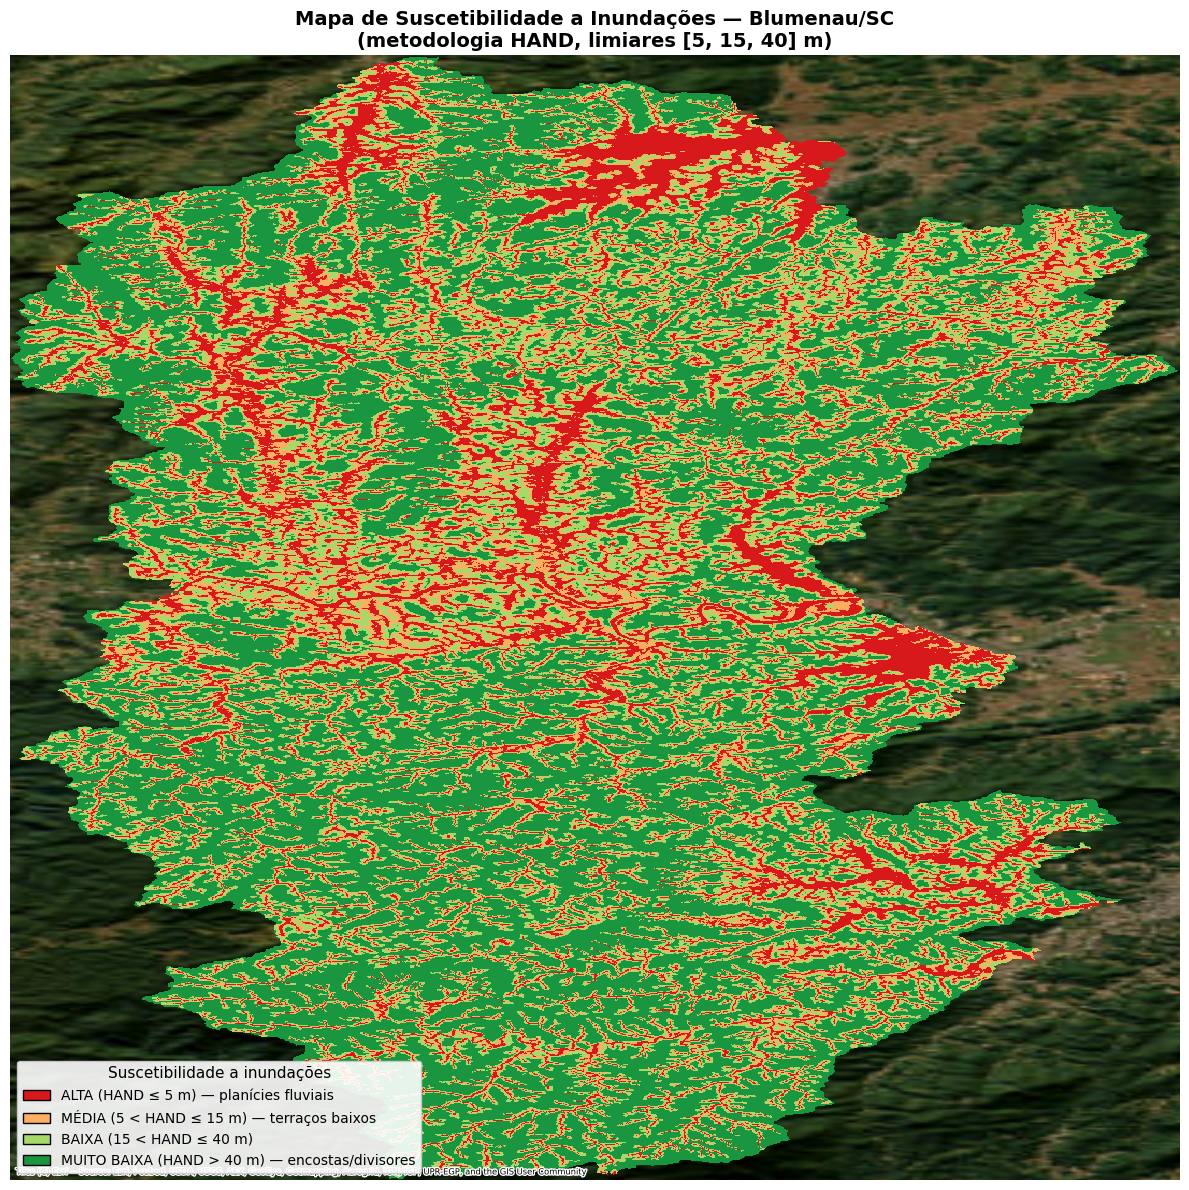


=== Estatísticas das classes de suscetibilidade ===
  Classe 0 (ALTO        ):     338004 pixels (16.75%)
  Classe 1 (MÉDIO       ):     285067 pixels (14.12%)
  Classe 2 (BAIXO       ):     482590 pixels (23.91%)
  Classe 3 (MUITO_BAIXO ):     912679 pixels (45.22%)


In [ ]:
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

t1, t2, t3 = hand_thresholds_m

r = (
    rxr.open_rasterio(hand, masked=True)
      .squeeze("band", drop=True)
      .astype("float32")
      .rio.reproject("EPSG:3857")
)

# ------------------------------------------------------------------
# Classificação determinística
# ------------------------------------------------------------------
# 0 = ALTO (HAND ≤ t1)
# 1 = MÉDIO (t1 < HAND ≤ t2)
# 2 = BAIXO (t2 < HAND ≤ t3)
# 3 = MUITO_BAIXO (HAND > t3)
# 255 = NoData

valid = xr.where(np.isfinite(r), True, False)
cls_da = xr.full_like(r, 255, dtype="uint8")

cls_da = cls_da.where(~(valid & (r <= t1)), 0)
cls_da = cls_da.where(~(valid & (r > t1) & (r <= t2)), 1)
cls_da = cls_da.where(~(valid & (r > t2) & (r <= t3)), 2)
cls_da = cls_da.where(~(valid & (r > t3)), 3)

cls_da.rio.write_nodata(255, inplace=True)

# Salvar GeoTIFF classificado (para uso futuro em SIG)
cls_tif = outdir / f"{prefix}_susceptibility_classes.tif"
cls_da.rio.to_raster(cls_tif, dtype="uint8")
print(f"Mapa de classes salvo: {cls_tif}")

# ------------------------------------------------------------------
# Plot com cores semáforo (vermelho = alto, verde = muito baixo)
# ------------------------------------------------------------------
colors_susc = ["#d7191c", "#fdae61", "#a6d96a", "#1a9641"]  # vermelho, laranja, verde claro, verde escuro
cmap_susc = mcolors.ListedColormap(colors_susc)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap_susc.N)

# 255 = transparente
r_plot = cls_da.where(cls_da != 255)

fig, ax = plt.subplots(figsize=(12, 12))

img = r_plot.plot(
    ax=ax,
    cmap=cmap_susc,
    norm=norm,
    add_colorbar=False,
    shading="auto"
)

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    crs=r_plot.rio.crs,
    attribution_size=6
)

# Legenda customizada (mais clara que colorbar contínua)
legend_elements = [
    Patch(facecolor=colors_susc[0], edgecolor="black",
          label=f"ALTA (HAND ≤ {t1} m) — planícies fluviais"),
    Patch(facecolor=colors_susc[1], edgecolor="black",
          label=f"MÉDIA ({t1} < HAND ≤ {t2} m) — terraços baixos"),
    Patch(facecolor=colors_susc[2], edgecolor="black",
          label=f"BAIXA ({t2} < HAND ≤ {t3} m)"),
    Patch(facecolor=colors_susc[3], edgecolor="black",
          label=f"MUITO BAIXA (HAND > {t3} m) — encostas/divisores"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=10,
          framealpha=0.9, title="Suscetibilidade a inundações",
          title_fontsize=11)

ax.set_axis_off()
ax.set_title(
    "Mapa de Suscetibilidade a Inundações — Blumenau/SC\n"
    f"(metodologia HAND, limiares {hand_thresholds_m} m)",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
fig_path = outdir / f"{prefix}_susceptibility_map.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Figura final salva em: {fig_path}")
plt.show()

# ------------------------------------------------------------------
# Estatísticas das classes (para o relatório)
# ------------------------------------------------------------------
print("\n=== Estatísticas das classes de suscetibilidade ===")
total_pixels = int((cls_da != 255).sum().item())
for cls_id, label in enumerate(risk_labels):
    n = int((cls_da == cls_id).sum().item())
    pct = 100.0 * n / total_pixels if total_pixels > 0 else 0.0
    print(f"  Classe {cls_id} ({label:12s}): {n:>10d} pixels ({pct:5.2f}%)")


## 9) Análise de sensibilidade dos limiares HAND

O Vale do Itajaí-Açu apresenta topografia mais montanhosa que a planície de Porto Alegre. Os limiares padrão `[5, 15, 40]` m foram calibrados para áreas de várzea ampla; para Blumenau, podem subestimar a suscetibilidade ao restringir demais a classe ALTA.

Aqui rodamos uma classificação alternativa com `[3, 10, 25]` m — limiares mais conservadores (menor tolerância de altura sobre drenagem) — e comparamos a distribuição percentual das classes.

In [ ]:
# Limiares alternativos para análise de sensibilidade
thresholds_alt = [3, 10, 25]
t1a, t2a, t3a = thresholds_alt

r_hand = (rxr.open_rasterio(hand, masked=True)
             .squeeze("band", drop=True)
             .astype("float32")
             .rio.reproject("EPSG:3857"))
valid_a = xr.where(np.isfinite(r_hand), True, False)
cls_alt = xr.full_like(r_hand, 255, dtype="uint8")
cls_alt = cls_alt.where(~(valid_a & (r_hand <= t1a)), 0)
cls_alt = cls_alt.where(~(valid_a & (r_hand > t1a) & (r_hand <= t2a)), 1)
cls_alt = cls_alt.where(~(valid_a & (r_hand > t2a) & (r_hand <= t3a)), 2)
cls_alt = cls_alt.where(~(valid_a & (r_hand > t3a)), 3)

print("=== Comparação: limiares padrão [5,15,40] m  vs  alternativos [3,10,25] m ===\n")
total_p = int((cls_da != 255).sum().item())
total_a = int((cls_alt != 255).sum().item())
print(f"{'Classe':12s} | {'Padrão %':>10s} | {'Alt. %':>10s} | {'Δ pp':>8s}")
print("-" * 50)
for cls_id, label in enumerate(risk_labels):
    n_p = int((cls_da == cls_id).sum().item())
    n_a = int((cls_alt == cls_id).sum().item())
    pct_p = 100.0 * n_p / total_p if total_p > 0 else 0.0
    pct_a = 100.0 * n_a / total_a if total_a > 0 else 0.0
    print(f"{label:12s} | {pct_p:>9.2f}% | {pct_a:>9.2f}% | {pct_a - pct_p:+7.2f}")


=== Comparação: limiares padrão [5,15,40] m  vs  alternativos [3,10,25] m ===

Classe       |   Padrão % |     Alt. % |     Δ pp
--------------------------------------------------
ALTO         |     16.75% |     12.70% |   -4.04
MÉDIO        |     14.12% |     11.90% |   -2.23
BAIXO        |     23.91% |     16.85% |   -7.06
MUITO_BAIXO  |     45.22% |     58.55% |  +13.33


## 10) Produtos exportados

Arquivos gerados em `outputs_hand/`:

- `hand_blumenau_hand.tif` — raster HAND contínuo (metros)
- `hand_blumenau_susceptibility_classes.tif` — raster classificado (0-3)
- `hand_blumenau_susceptibility_map.png` — figura final do relatório

E em `outputs_dem/`:

- `blumenau_boundary.gpkg` — limite municipal IBGE
- `ottobacias_blumenau_raw.gpkg` — ottobacias BHO/ANA brutas
- `ottobacias_blumenau_union.gpkg` — contorno final de recorte do DEM
- `dem_contrib_clipped.tif` — DEM recortado pelo contorno
- `fig01_ottobacias_blumenau.png`, `fig02_dem_blumenau.png` — quicklooks

Todos os GeoTIFFs estão em **EPSG:3857** (Web Mercator) para compatibilidade direta com basemaps Esri/OpenStreetMap.

*Este estudo representa uma suscetibilidade geomorfológica à inundação baseada no índice HAND. Não substitui modelagem hidráulica 1D/2D, cartas oficiais de inundação ou validação com eventos históricos. O mapa deve ser interpretado como uma camada exploratória de apoio à análise territorial.*

In [ ]:
# COPIA OS FINAIS DE /content/work_hand/ PARA O SEU MyDrive
# (execute ANTES de desligar o PC ou fechar a aba)
import shutil
from pathlib import Path

src = Path("/content/work_hand")
dst = Path("/content/drive/MyDrive/HAND_BLUMENAU/outputs_hand")
dst.mkdir(parents=True, exist_ok=True)

# Lista do que copiar (pula intermediários gigantes — só o que importa pro relatório)
files_to_keep = [
    "hand_blumenau_hand.tif",                          # raster HAND contínuo
    "hand_blumenau_susceptibility_classes.tif",        # raster classificado
    "hand_blumenau_susceptibility_map.png",            # FIGURA PRO RELATÓRIO
]

copied = []
missing = []
for fname in files_to_keep:
    s = src / fname
    if s.exists():
        shutil.copy(s, dst / fname)
        size_mb = (dst / fname).stat().st_size / 1e6
        copied.append((fname, size_mb))
        print(f"✓ {fname}  ({size_mb:.1f} MB) → {dst}")
    else:
        missing.append(fname)
        print(f"· {fname} não existe ainda — rode as células anteriores")

print(f"\n{len(copied)} arquivo(s) salvo(s) no Drive. {len(missing)} pendente(s).")
print(f"Local final: {dst}")

✓ hand_blumenau_hand.tif  (27.0 MB) → /content/drive/MyDrive/HAND_BLUMENAU/outputs_hand
✓ hand_blumenau_susceptibility_classes.tif  (3.1 MB) → /content/drive/MyDrive/HAND_BLUMENAU/outputs_hand
✓ hand_blumenau_susceptibility_map.png  (2.3 MB) → /content/drive/MyDrive/HAND_BLUMENAU/outputs_hand

3 arquivo(s) salvo(s) no Drive. 0 pendente(s).
Local final: /content/drive/MyDrive/HAND_BLUMENAU/outputs_hand
